### 데이터의 불균형 문제
- 정상을 정확하게 분류하는 것과 이상을 정확하게 분류하는 것 중 이상을 정확하게 분류하는 것이 중요
- 일반적으로는 정상의 데이터가 이상의 데이터보다 많다
- 데이터의 불균형이 발생할 수 있다
- target 데이터에서 0(정상), 1(이상) 중에 0을 판단을 더 많이하게 되는 경우가 발생(에측력이 떨어진다)
- 소수의 데이터의 중요도가 낮게 판단이 되서 실제 모델에서는 해당하는 예측이 적게 발생
- 다수의 데이터와 소수의 데이터를 특정 비율로 조절해주는 샘플링 기법이 존재(언더 샘플링, 오버 샘플링)
- 샘플링을 사용하기 위한 라이브러리 설치 (imbalanced-learn)

In [48]:
# !pip install imbalanced-learn

- 언더 샘플링
    - 다수의 라벨을 가진 데이터를 샘플링하여 소수의 데이터의 수 수준으로 감소 시키는 방법
    - 데이터의 불균형 문제는 해결이 되지만 전체 데이터의 개수가 감소하여 학습의 성능이 떨어질 수 있다
    

In [49]:
import pandas as pd
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [50]:
# 머신러닝에서는 독립 변수의 종속 변수를 이용
# make_classification() 함수는 데이터가 불균형한 랜덤 데이터를 생성 결과가 독립변수, 종속변수 따로 데이터를 제공

# 불균형 데이터셋 생성
x, y = make_classification(
    n_samples = 1000,
    n_features = 5,
    weights = [0.9],
    flip_y=0
)

In [51]:
x

array([[ 0.99857301, -0.35289366, -0.89101329, -0.63006678, -0.5574229 ],
       [-0.31271007,  0.23621106,  0.23860398, -1.19311884,  0.33351635],
       [ 1.53893762, -0.65669612, -1.33688632,  0.52622111, -1.00175659],
       ...,
       [-1.2049592 ,  0.58912833,  1.02265493, -0.50619818,  0.87913254],
       [-0.57549349,  0.63237244,  0.37554771, -0.10876352,  0.86374183],
       [ 1.68090917, -0.2695387 , -1.60420365, -2.11065083, -0.52797675]])

In [52]:
y

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,

In [53]:
Counter(y)

Counter({0: 901, 1: 99})

In [54]:
# 데이터프레임으로 생성
df = pd.DataFrame(x)
# target 데이터 y도 데이터프레임에 포함
df['target'] = y

df.head()

,0,1,2,3,4,target
0,0.998573,-0.352894,-0.891013,-0.630067,-0.557423,0
1,-0.312710,0.236211,0.238604,-1.193119,0.333516,0
2,1.538938,-0.656696,-1.336886,0.526221,-1.001757,0
3,2.273323,-1.580418,-1.778576,1.599040,-2.251616,0
4,-0.028224,0.824689,-0.236814,-0.211482,1.046013,0


In [55]:
# RandomUnderSampler 라는 class를 생성
undersampler = RandomUnderSampler()

In [56]:
under_x, under_y = undersampler.fit_resample(x, y)

In [57]:
Counter(under_y)

Counter({0: 99, 1: 99})

In [58]:
under_df = pd.DataFrame(under_x)
under_df['target'] = under_y
under_df['target'].value_counts()

target
0    99
1    99
Name: count, dtype: int64

In [59]:
# undersampler에서 데이터의 비율을 변경
# class 생성할때 비율을 지정
# sampling_stratefy 매개변수 -> 소수의 데이터의 비율을 의미
undersampler2 = RandomUnderSampler(sampling_strategy=0.5)

In [60]:
x_under2, y_under2 = undersampler2.fit_resample(x,y)

In [61]:
Counter(y_under2)

Counter({0: 198, 1: 99})

- 오버 샘플링
    - 소수의 데이터를 다수의 데이터의 개수만큼 증가시켜서 학습에 사용하기 위한 방법
    - 데이터의 손실이 없기 때문에 일반적으로는 언더 샘플링보다는 자주 사용

- 랜덤오버샘플링
    - 소수의 데이터를 단순 복제하여 다수의 데이터와의 비율을 맞춰주는 과정
    - 데이터가 단순하게 복제가 되기 때문에 분포가 변하지 않는다
    - 단순하게 증가시키기 때문에 추가적인 가중치가 발생
    - 오버피팅의 위험성이 존재하지만 데이터 불균형 문제를 해결하는 것이 더 중요

In [62]:
from imblearn.over_sampling import RandomOverSampler

In [63]:
oversampler = RandomOverSampler()

In [64]:
over_x, over_y = oversampler.fit_resample(x, y)

In [65]:
Counter(over_y)

Counter({0: 901, 1: 901})

In [66]:
# 소수의 데이터 비율을 다수의 반정도로 샘플링
oversampler2 = RandomOverSampler(sampling_strategy=0.5)

In [67]:
over_x2, over_y2 = oversampler2.fit_resample(x, y)

In [68]:
Counter(over_y2)

Counter({0: 901, 1: 450})

- SMOTE
    - 소수의 데이터의 관측값에 대한 K개의 최근접 양수를 이웃으로 찾고, 관측값과 이웃으로 선택된 값 사이에 임의의 새로운 데이터를 생성하는 방법

In [69]:
from imblearn.over_sampling import SMOTE

In [70]:
smote = SMOTE()

In [71]:
sm_x, sm_y = smote.fit_resample(x,y)

In [72]:
Counter(sm_y)

Counter({0: 901, 1: 901})

In [73]:
# 실제 만들어진 샘플링 데이터의 분포를 확인
sm_x

array([[ 0.99857301, -0.35289366, -0.89101329, -0.63006678, -0.5574229 ],
       [-0.31271007,  0.23621106,  0.23860398, -1.19311884,  0.33351635],
       [ 1.53893762, -0.65669612, -1.33688632,  0.52622111, -1.00175659],
       ...,
       [-0.28061238, -1.04079651,  0.61698024,  2.1074677 , -1.2849133 ],
       [ 0.74721229, -1.46451587, -0.2806819 , -0.05449183, -1.93515621],
       [ 0.42925883, -1.32584984, -0.00543457, -0.63004489, -1.72440796]])

In [74]:
# 실제 만들어진 샘플링 데이터의 분포를 확인
import matplotlib.pyplot as plt
import seaborn as sns

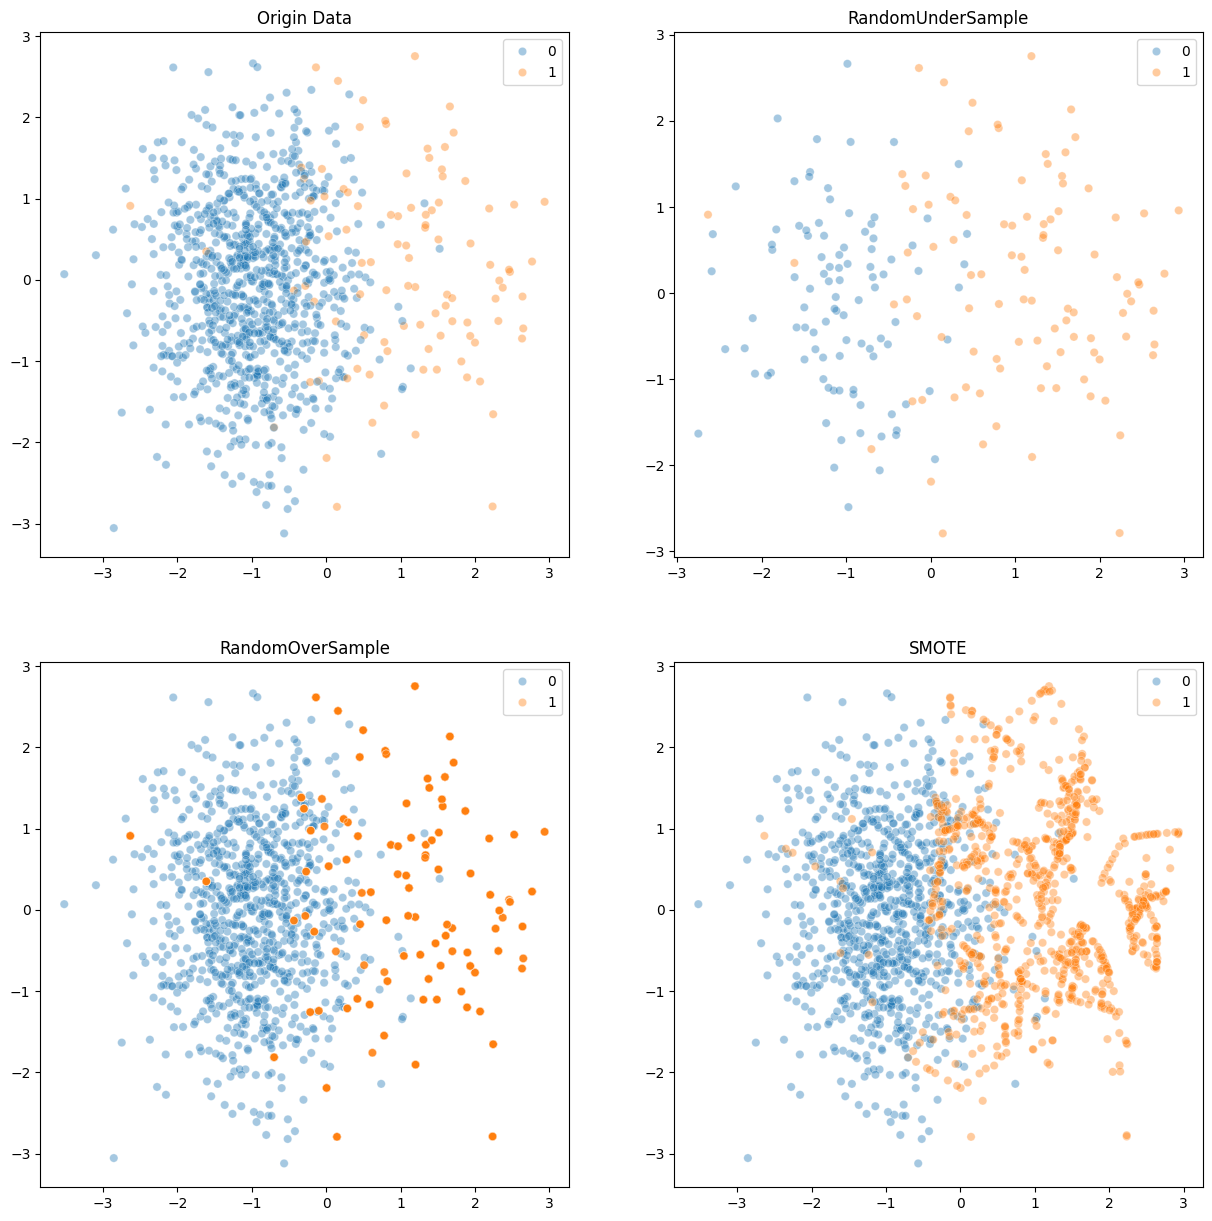

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(15,15))

# 4개의 산점도 그래프 생성
sns.scatterplot(
    x = x[:, 2], y=x[:, 3], ax = axes[0][0], hue = y, alpha = 0.4
)
sns.scatterplot(
    x = under_x[:,2], y = under_x[:,3], ax = axes[0][1], hue = under_y, alpha = 0.4
)
sns.scatterplot(
    x = over_x[:,2],y = over_x[:,3], ax = axes[1][0], hue = over_y, alpha = 0.4
)
sns.scatterplot(
    x = sm_x[:,2], y = sm_x[:,3], ax = axes[1][1], hue = sm_y, alpha = 0.4
)
axes[0][0].set_title('Origin Data')
axes[0][1].set_title('RandomUnderSample')
axes[1][0].set_title('RandomOverSample')
axes[1][1].set_title('SMOTE')

plt.show()